<Axes: >

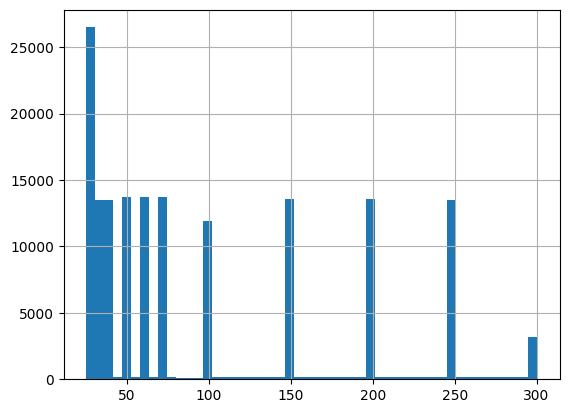

In [62]:
import pandas as pd

df_raw = pd.read_csv(
    "DATA_TP/SweepBcl",
    header=None,
    sep="\t",
)

df = df_raw.iloc[:, [0, 1, 2, 12, 13]].set_axis(['step', 'temp', 'mag', 'vxx', 'vxy'], axis=1)
df.temp.hist(bins=50)

In [63]:
from sklearn import metrics
from sklearn.cluster import DBSCAN


clustering = DBSCAN(eps=0.5, min_samples=100).fit(df.temp.values.reshape(-1, 1))
print(len(set(clustering.labels_)))

13


In [64]:
df['temp_cluster'] = clustering.labels_

59.0331 60.9965 60.00024852617686


<Axes: xlabel='mag'>

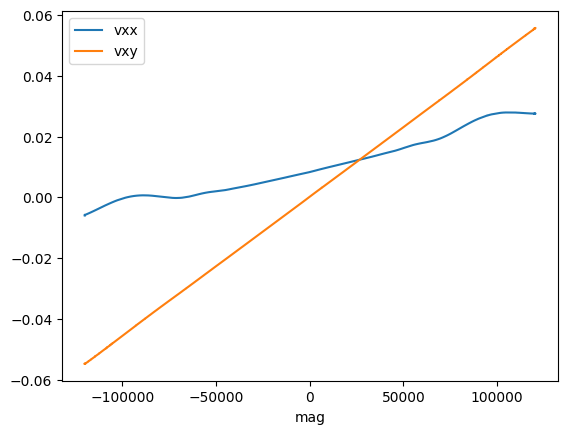

In [108]:

df_0 = df[df.temp_cluster == 5]

print(df_0.temp.min(), df_0.temp.max(), df_0.temp.mean())

df_0.plot.line(x="mag", y=["vxx", "vxy"])

In [109]:
import numpy as np

def process_measurement(B, Vxx, Vxy):
    a_vxx0 = Vxx + np.interp(B * -1, B, Vxx)
    b_vxy0 = Vxx - np.interp(B * -1, B, Vxx)
    c_vxx0 = Vxy + np.interp(B * -1, B, Vxy)
    d_vxy0 = Vxy - np.interp(B * -1, B, Vxy)

    return a_vxx0/2, b_vxy0/2, c_vxx0/2, d_vxy0/2

def density_from_Vh(Vh, B, I, e):
    """
    Vh: Tension de Hall (V)
    B: Champ magnetique (T)
    I: Intensité (A)
    e: epaisseur (m)
    """
    q = 1.6E-19         # charge elementaire (C)

    Vh = np.array(Vh)
    B = np.array(B)

    coeffs = np.polyfit(B, Vh, 1)
    slope = coeffs[0]
    intercept = coeffs[1]

    n = I / (q * e * slope)

    print("Slope dVh/dB =", slope, "V/T")
    print("Densité n =", n, "m^-3")

    return n, slope

def full_process(df, t0, t1):
    pass

In [110]:
measurements = process_measurement(df_0.mag, df_0.vxx, df_0.vxy)
df_0["a_vxx0"] = measurements[0]
df_0["b_vxy0"] = measurements[1]
df_0["c_vxx0"] = measurements[2]
df_0["d_vxy0"] = measurements[3]

<Axes: xlabel='mag'>

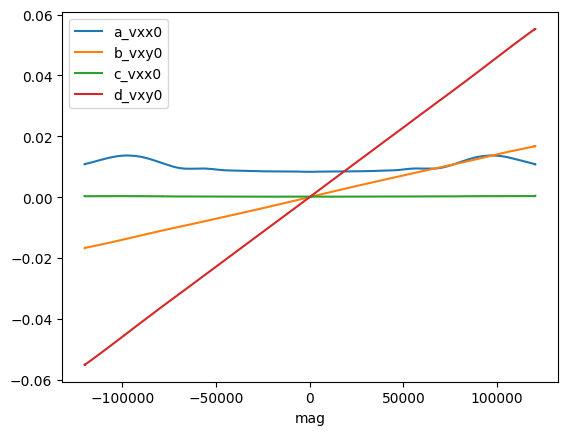

In [111]:
df_0.plot.line(x="mag", y=[
    "a_vxx0",
    "b_vxy0",
    "c_vxx0",
    "d_vxy0",
])

In [112]:
I = 2 *1E-3
Umag = 1E-4
Uv = 1/100

e = 0.5e-3                 # epaisseur (m)

Vh = np.array(df_0["d_vxy0"] * Uv)
B = np.array(df_0["mag"] * Umag)

n , slope = density_from_Vh(Vh, B, I, e)

Slope dVh/dB = 4.590472785680824e-05 V/T
Densité n = 5.446062130677068e+23 m^-3


In [113]:
id0 = df_0.loc[df["mag"] < 0, "mag"].idxmax()
id1 = df_0.loc[df["mag"] > 0, "mag"].idxmin()
start = min(id0, id1)
end   = max(id0, id1)

Vxx0 = df_0.loc[start: end].vxx.mean()
print(Vxx0)

df_0.loc[start: end]

0.008307515


,step,temp,mag,vxx,vxy,temp_cluster,a_vxx0,b_vxy0,c_vxx0,d_vxy0
74361,74362.0,59.9981,-16.172,0.008303,0.000160,5,0.008307,-0.000005,0.000169,-0.000009
74362,74363.0,59.9981,13.993,0.008312,0.000175,5,0.008308,0.000004,0.000168,0.000007


In [114]:
e = 0.5e-3                 # epaisseur (m)
la = 1.46e-3            # largeur (m)
lo = 5.36e-3            # longueur (m)
q = 1.6E-19         # charge elementaire (C)

Vxx0 = Vxx0 * Uv
S = e * la

rhoxx = (Vxx0 / I) * (S / lo)
rhoxx

np.float64(5.657169729477612e-06)

In [115]:
mu = (1 / (rhoxx * n * q)) * 10000
mu

np.float64(20286.083877603192)

In [ ]:
T = 25, n2d = 1.13 E24, Vxx0 = 0.0085, Rhoxx = 5.82 E-6, mu = 9482
T = 60, n2d = 5.44 E23, Vxx0 = 0.0083, Rhoxx = 5.65 E-6, mu = 20286